In [1]:
# 1. SETUP & DEPENDENCIES
import os
import sys
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display
import firebase_admin
from firebase_admin import credentials, db
import warnings
warnings.filterwarnings('ignore')

# Matplotlib settings
sns.set_theme(style="whitegrid")
%matplotlib inline

# Constants
STATIONS = ['id-01', 'id-02', 'id-03', 'id-04', 'id-05']
CACHE_DIR = "cache_data"
if not os.path.exists(CACHE_DIR):
    os.makedirs(CACHE_DIR)

# FIREBASE AUTHENTICATION
if not firebase_admin._apps:
    try:
        cred = credentials.Certificate('D:/staklimjerukagung-firebase-adminsdk-kcfma-e091165a9b.json')
        firebase_admin.initialize_app(cred, {
            'databaseURL': 'https://staklimjerukagung-default-rtdb.asia-southeast1.firebasedatabase.app/'
        })
        display(Markdown("> ✅ **Firebase Initialized Successfully**"))
    except FileNotFoundError:
        display(Markdown("> ❌ **Error: Credential file not found!**"))
else:
    display(Markdown("> ✅ **Firebase Already Initialized**"))


> ✅ **Firebase Initialized Successfully**

In [2]:
# 2. CHUNKED BIG DATA RETRIEVAL ENGINE & INCREMENTAL UPDATE
def fetch_and_cache_data_chunked(station_id, chunk_size=500000):
    cache_path = os.path.join(CACHE_DIR, f"{station_id}_raw.parquet")
    
    df_existing = pd.DataFrame()
    last_key = None
    
    if os.path.exists(cache_path):
        try:
            df_existing = pd.read_parquet(cache_path)
            if not df_existing.empty:
                max_ts = df_existing['timestamp'].max()
                last_key = str(int(max_ts))
                display(Markdown(f"✅ Loaded `{station_id}` from cache. Fetching new data since `{last_key}`..."))
        except Exception as e:
            display(Markdown(f"⚠️ Failed to read cache `{station_id}`: {e}. Re-downloading full dataset..."))
            df_existing = pd.DataFrame()
            last_key = None
    else:
        display(Markdown(f"⏳ Downloading `{station_id}` from scratch..."))
        
    ref = db.reference(f'/auto_weather_stat/{station_id}/data')
    all_data = {}
    total_fetched = 0
    
    while True:
        query = ref.order_by_key().limit_to_first(chunk_size)
        if last_key:
            query = query.start_at(last_key)
            
        try:
            chunk = query.get()
        except Exception as e:
            display(Markdown(f"⚠️ Error fetching `{station_id}`: {e}"))
            break
            
        if not chunk:
            break
            
        keys = list(chunk.keys())
        # Prevent infinite loop by removing the overlapping last_key
        if last_key and keys[0] == last_key:
            del chunk[keys[0]]
            keys = keys[1:]
            
        if not chunk:
            break
            
        all_data.update(chunk)
        last_key = keys[-1]
        total_fetched += len(keys)
        
        # If we received less than chunk_size, we've reached the end
        if len(keys) < (chunk_size - 1):
            break
            
    if not all_data:
        if not df_existing.empty:
            display(Markdown(f"👍 `{station_id}` is up to date! Total records: {len(df_existing):,}"))
            return df_existing
        else:
            display(Markdown(f"⚠️ No data found for `{station_id}`."))
            return pd.DataFrame()
            
    # Format new data
    df_new = pd.DataFrame.from_dict(all_data, orient='index')
    
    if 'timestamp' not in df_new.columns:
        df_new['timestamp'] = df_new.index
    else:
        df_new['timestamp'] = df_new['timestamp'].fillna(pd.Series(df_new.index, index=df_new.index))
        
    df_new['timestamp'] = pd.to_numeric(df_new['timestamp'], errors='coerce')
    df_new = df_new.dropna(subset=['timestamp'])
    df_new['timestamp'] = df_new['timestamp'].astype(int)
    
    # Merge existing and new
    if not df_existing.empty:
        df_combined = pd.concat([df_existing, df_new])
        # Prioritaskan data terbaru (keep='last') jika ada duplikat berdasarkan timestamp
        df_combined = df_combined.drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)
    else:
        df_combined = df_new.reset_index(drop=True)
        
    # Perbaiki tipe data campuran menjadi float agar kompatibel dengan Parquet
    for col in df_combined.columns:
        if col != 'timestamp' and df_combined[col].dtype == 'object':
            df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
        
    df_combined.to_parquet(cache_path, index=False)
    display(Markdown(f"💾 Saved `{station_id}` ({total_fetched:,} new records) to cache. Total records: {len(df_combined):,}"))
    return df_combined

dfs = {}
for st in STATIONS:
    df = fetch_and_cache_data_chunked(st)
    if not df.empty:
        dfs[st] = df


✅ Loaded `id-01` from cache. Fetching new data since `1780901505`...

💾 Saved `id-01` (368 new records) to cache. Total records: 273,183

✅ Loaded `id-02` from cache. Fetching new data since `1780901546`...

💾 Saved `id-02` (311 new records) to cache. Total records: 35,681

✅ Loaded `id-03` from cache. Fetching new data since `1780901547`...

💾 Saved `id-03` (377 new records) to cache. Total records: 1,387,468

✅ Loaded `id-04` from cache. Fetching new data since `1780721028`...

👍 `id-04` is up to date! Total records: 229,886

✅ Loaded `id-05` from cache. Fetching new data since `1780901511`...

💾 Saved `id-05` (309 new records) to cache. Total records: 744,361

In [3]:
# 3. FORENSIC AUDIT ENGINE & SCORING
def perform_forensic_audit(df, station_id):
    audit = {}
    
    # 1. Konversi waktu dan pengurutan
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s', utc=True).dt.tz_convert('Asia/Jakarta')
    df = df.sort_values('datetime').reset_index(drop=True)
    
    # Deteksi Absolute Duplicates
    audit['absolute_duplicates'] = df.duplicated(subset=['timestamp']).sum()
    
    # Filter duplikat waktu untuk analisis kontinu
    df['minute_floor'] = df['datetime'].dt.floor('T')
    counts_per_min = df.groupby('minute_floor').size()
    
    # Burst Anomalies (>2 data per menit)
    bursts = counts_per_min[counts_per_min > 2]
    audit['burst_anomalies_count'] = len(bursts)
    
    # Clean up duplikat absolut untuk completeness check
    df_clean = df.drop_duplicates(subset=['minute_floor'], keep='first').copy()
    
    if len(df_clean) < 2:
        return None
        
    min_time = df_clean['minute_floor'].min()
    max_time = df_clean['minute_floor'].max()
    
    # Hitung Time Reversals (Waktu mundur) pada dataset asli
    time_diffs = df['timestamp'].diff()
    audit['time_reversals'] = (time_diffs < 0).sum()
    
    # 2. Completeness Check
    # Expected points: 1440 * number of active days (rounded)
    span_days = (max_time - min_time).total_seconds() / 86400.0
    # Add 1 day to account for partial days rounding up
    span_days = max(1, int(np.ceil(span_days))) 
    expected_records = span_days * 1440
    
    audit['total_expected'] = expected_records
    audit['total_received'] = len(df_clean)
    audit['total_missing'] = max(0, audit['total_expected'] - audit['total_received'])
    audit['completeness_pct'] = min(100.0, (audit['total_received'] / audit['total_expected']) * 100)
    
    # 3. Continuity & Gap Analysis
    df_clean.set_index('minute_floor', inplace=True)
    expected_timeline = pd.date_range(start=min_time, end=max_time, freq='1T')
    missing_times = expected_timeline.difference(df_clean.index)
    audit['missing_times'] = missing_times
    
    # Fragmentasi Index (Berapa banyak gap yang terpisah)
    if len(missing_times) > 0:
        missing_df = pd.DataFrame({'time': missing_times})
        missing_df['diff'] = missing_df['time'].diff()
        blocks = (missing_df['diff'] != pd.Timedelta(minutes=1)).cumsum()
        gap_summary = missing_df.groupby(blocks).agg(
            start=('time', 'min'),
            end=('time', 'max'),
            duration_mins=('time', 'count')
        )
        audit['fragmentation_index'] = len(gap_summary) # Jumlah insiden mati
        audit['max_gap_duration'] = gap_summary['duration_mins'].max()
        audit['gap_summary'] = gap_summary.sort_values('duration_mins', ascending=False)
    else:
        audit['fragmentation_index'] = 0
        audit['max_gap_duration'] = 0
        audit['gap_summary'] = pd.DataFrame()
        
    audit['start_time'] = min_time
    audit['end_time'] = max_time
    
    # 4. Big Data Reliability Scoring (0-100)
    # Completeness Score (Weight: 60%)
    score_comp = audit['completeness_pct'] * 0.60
    
    # Consistency Score (Weight: 20%)
    # Penalti jika ada time reversals atau banyak burst
    consistency_penalty = min(100, (audit['time_reversals'] * 5) + (audit['burst_anomalies_count'] * 0.5))
    score_consist = max(0, (100 - consistency_penalty)) * 0.20
    
    # Continuity Score (Weight: 20%)
    # Penalti jika max_gap sangat besar (berhari-hari) atau fragmen sangat tinggi
    continuity_penalty = min(100, (audit['max_gap_duration'] / 1440 * 10) + (audit['fragmentation_index'] * 0.5))
    score_cont = max(0, (100 - continuity_penalty)) * 0.20
    
    audit['quality_score'] = score_comp + score_consist + score_cont
    
    return audit

reports = {}
for st in STATIONS:
    if st in dfs:
        reports[st] = perform_forensic_audit(dfs[st], st)


In [4]:
# 4. SYSTEMIC FAILURE DETECTION ENGINE
def detect_systemic_failure(reports):
    # Temukan waktu kosong yang terjadi bersamaan di berbagai stasiun
    missing_dict = {}
    for st, r in reports.items():
        if r is not None and len(r['missing_times']) > 0:
            for mt in r['missing_times']:
                if mt not in missing_dict:
                    missing_dict[mt] = []
                missing_dict[mt].append(st)
                
    if not missing_dict:
        return "Tidak ditemukan data hilang sistemik (Cross-station correlation = 0)."
        
    # Hitung waktu dimana > 2 stasiun mati bersamaan
    systemic_times = {k: v for k, v in missing_dict.items() if len(v) >= 3}
    
    if len(systemic_times) == 0:
        return "Kegagalan bersifat terisolasi (Isolated Station Failures). Kemungkinan masalah pada baterai sensor masing-masing."
        
    sys_df = pd.DataFrame({'time': list(systemic_times.keys())}).sort_values('time')
    sys_df['diff'] = sys_df['time'].diff()
    blocks = (sys_df['diff'] != pd.Timedelta(minutes=1)).cumsum()
    
    sys_gaps = sys_df.groupby(blocks).agg(
        start=('time', 'min'),
        end=('time', 'max'),
        duration=('time', 'count')
    ).sort_values('duration', ascending=False)
    
    insight = f"🚨 **SYSTEMIC FAILURE DETECTED!** Terdapat {len(sys_gaps)} insiden dimana >=3 stasiun mati serentak.\n"
    insight += "Ini mengindikasikan matinya Gateway Node utama (Internet Down) atau pemadaman PLN pusat.\n\n"
    insight += "**Top 3 Pemadaman Massal:**\n"
    
    for _, row in sys_gaps.head(3).iterrows():
        insight += f"- Dari `{row['start'].strftime('%Y-%m-%d %H:%M')}` ke `{row['end'].strftime('%Y-%m-%d %H:%M')}` ({row['duration']} menit)\n"
        
    return insight

systemic_insight_md = detect_systemic_failure(reports)


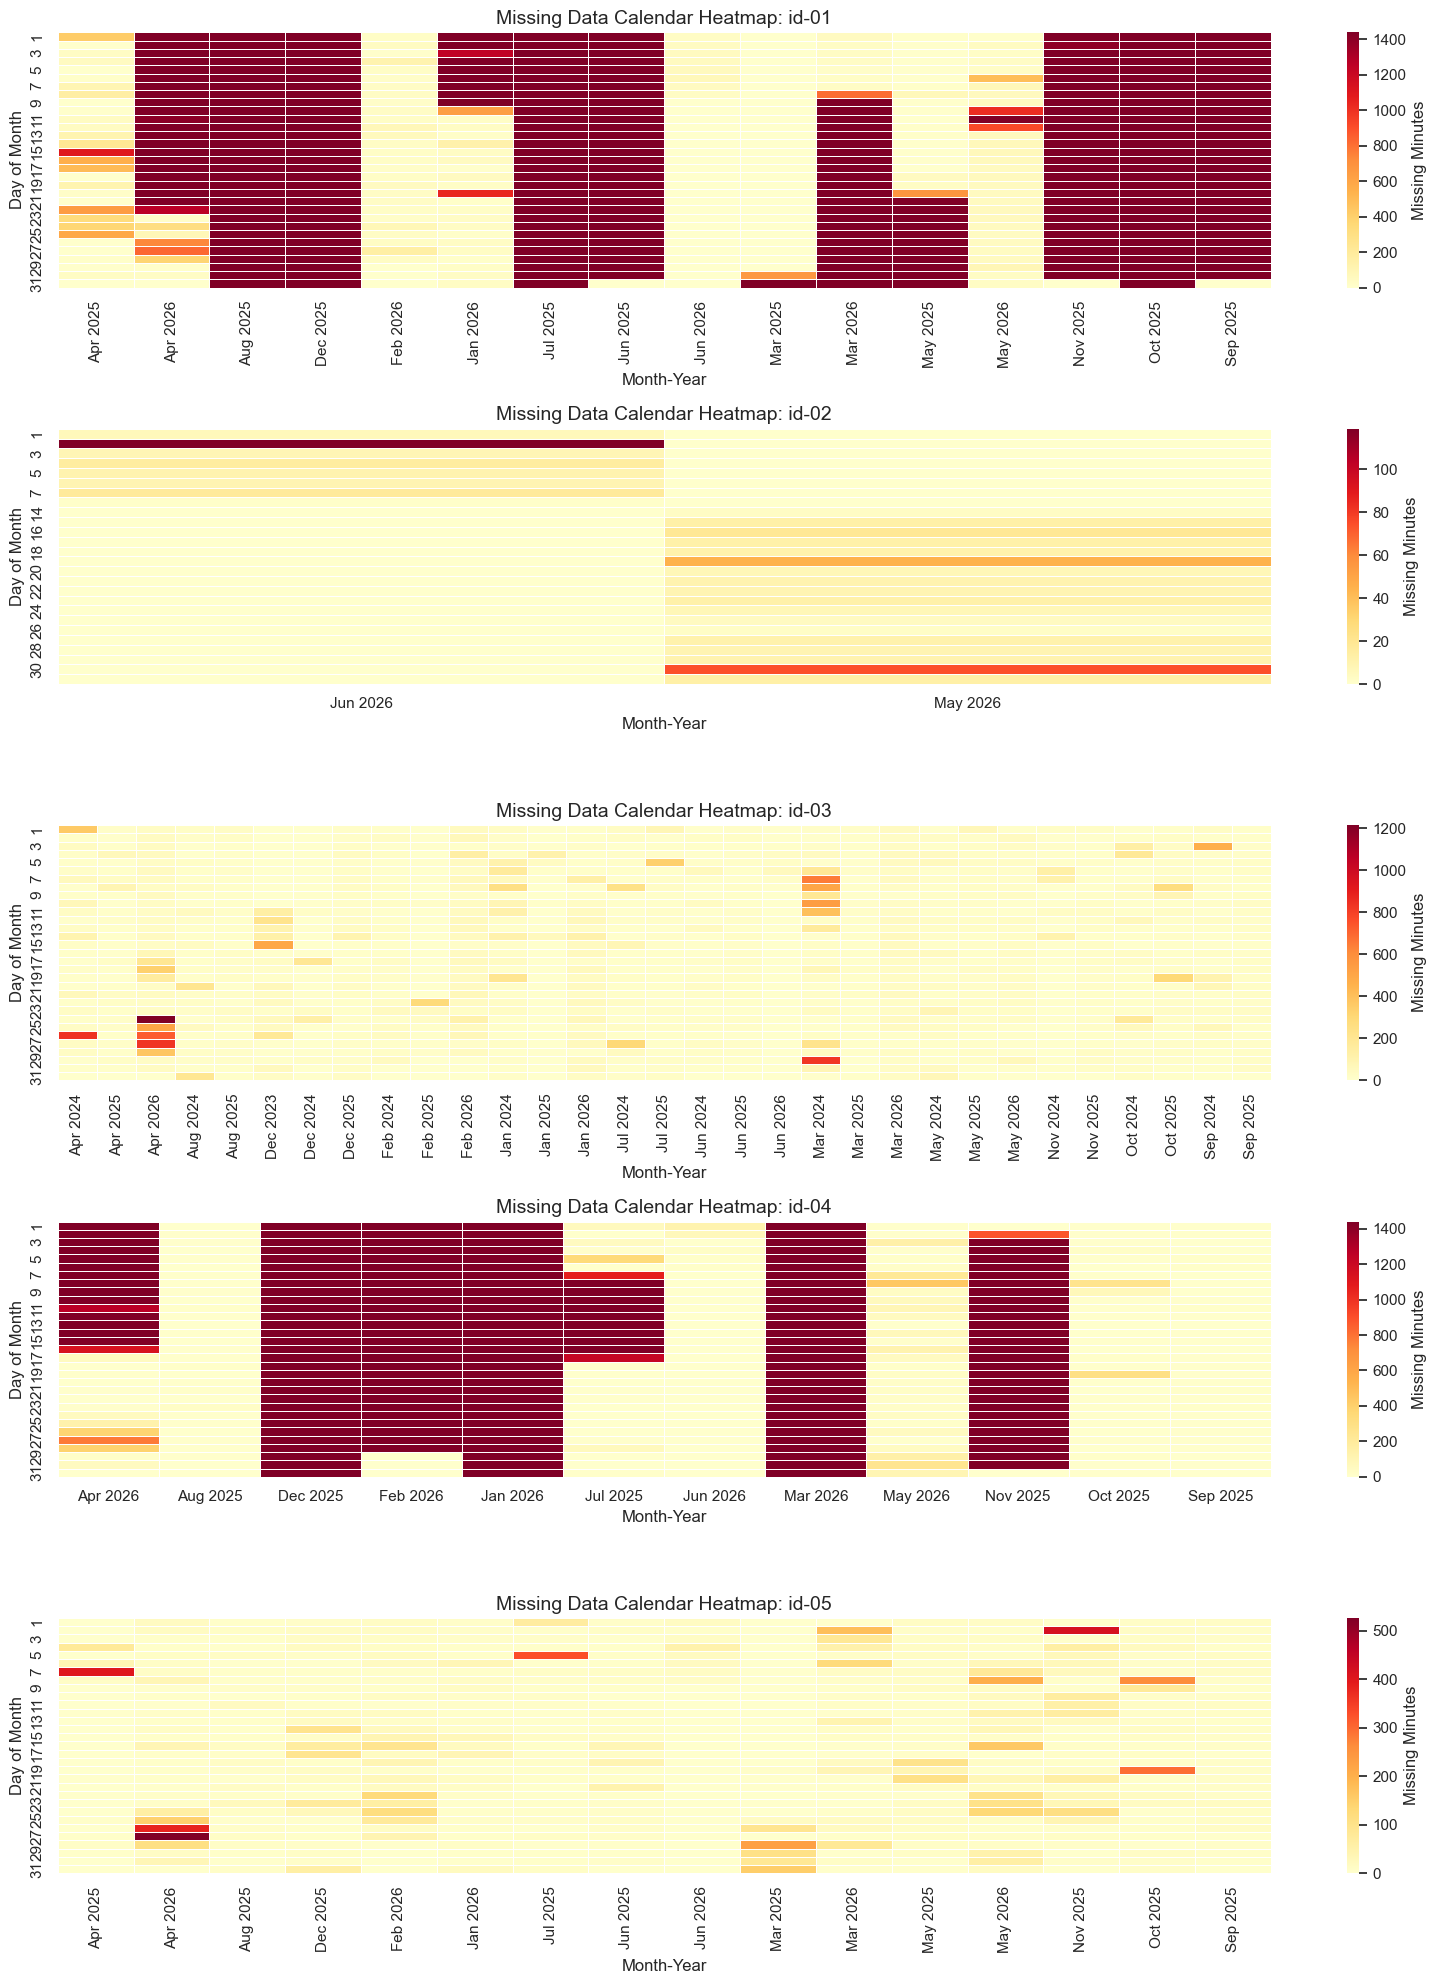

In [5]:
# 5. FORENSIC VISUALIZATIONS (HEATMAPS & COMPLETENESS)
def plot_heatmaps(reports):
    fig, axes = plt.subplots(len(reports), 1, figsize=(16, 4 * len(reports)))
    if len(reports) == 1:
        axes = [axes]
        
    for idx, (st, r) in enumerate(reports.items()):
        ax = axes[idx]
        if r is None or len(r['missing_times']) == 0:
            ax.text(0.5, 0.5, f"No Missing Data for {st}", ha='center', fontsize=14)
            ax.axis('off')
            continue
            
        # Buat dataframe untuk missing times
        mdf = pd.DataFrame({'time': r['missing_times']})
        mdf['month_year'] = mdf['time'].dt.strftime('%b %Y')
        mdf['day'] = mdf['time'].dt.day
        
        pivot = mdf.groupby(['day', 'month_year']).size().unstack(fill_value=0)
        
        sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=.5, cbar_kws={'label': 'Missing Minutes'})
        ax.set_title(f"Missing Data Calendar Heatmap: {st}", fontsize=14)
        ax.set_ylabel("Day of Month")
        ax.set_xlabel("Month-Year")
        
    plt.tight_layout()
    plt.show()

plot_heatmaps(reports)


In [6]:
# 6. GENERATE FINAL FORENSIC MARKDOWN REPORT
report_md = "# 🕵️ Forensic Meteorological Data Audit Report\n\n"

# A. Executive Summary
report_md += "## A. Executive Summary\n"
report_md += "| Station ID | Expected Points | Received | Missing | Duplicates | Burst Anomalies | Reversals | Completeness | Quality Score | Health |\n"
report_md += "|------------|-----------------|----------|---------|------------|-----------------|-----------|--------------|---------------|--------|\n"

best_score = -1
best_station = "N/A"

for st in STATIONS:
    if st in reports and reports[st] is not None:
        r = reports[st]
        score = r['quality_score']
        health = "🟢 Excellent" if score > 85 else ("🟡 Fair" if score > 60 else "🔴 Critical")
        report_md += f"| **{st}** | {r['total_expected']:,} | {r['total_received']:,} | {r['total_missing']:,} | {r['absolute_duplicates']:,} | {r['burst_anomalies_count']:,} | {r['time_reversals']:,} | {r['completeness_pct']:.2f}% | **{score:.2f} / 100** | {health} |\n"
        
        if score > best_score:
            best_score = score
            best_station = st
    else:
        report_md += f"| **{st}** | N/A | N/A | N/A | N/A | N/A | N/A | N/A | N/A | ⚪ No Data |\n"

report_md += f"\n> 🏆 **Most Reliable Station:** `{best_station}` with score `{best_score:.2f} / 100`.\n\n"

# B. Systemic Insights
report_md += "## B. Big Data Systemic Insight\n"
report_md += systemic_insight_md + "\n\n"

# C. Detailed Forensic Report
report_md += "## C. Detailed Forensic Analysis\n"
for st in STATIONS:
    if st in reports and reports[st] is not None:
        r = reports[st]
        report_md += f"### Station: `{st}`\n"
        report_md += f"- **Time Range:** {r['start_time'].strftime('%Y-%m-%d %H:%M:%S')} to {r['end_time'].strftime('%Y-%m-%d %H:%M:%S')}\n"
        report_md += f"- **Exact Time Duplicates:** {r['absolute_duplicates']:,} redundant records.\n"
        report_md += f"- **Fragmentation Index:** {r['fragmentation_index']} discrete blackout events.\n"
        
        if not r['gap_summary'].empty:
            report_md += "- **Top 3 Longest Downtime Gaps:**\n"
            for _, row in r['gap_summary'].head(3).iterrows():
                report_md += f"  - From `{row['start'].strftime('%Y-%m-%d %H:%M')}` to `{row['end'].strftime('%Y-%m-%d %H:%M')}` ({row['duration_mins']} minutes)\n"
        
        # Root cause hypothesis per station
        report_md += "- **Forensic Hypothesis:** "
        if r['burst_anomalies_count'] > 50:
            report_md += "High burst rate indicates *network queuing* or *LoRa packet collision* where data is buffered and sent in bursts. "
        if r['max_gap_duration'] > 720:
            report_md += "Severe gaps (>12h) suggest *Solar Power Failure* or complete battery drain overnight. "
        if r['fragmentation_index'] > 100 and r['max_gap_duration'] < 60:
            report_md += "High fragmentation with short gaps indicates *sporadic packet loss* over the radio interface (RSSI/SNR issues). "
        if r['quality_score'] > 90:
            report_md += "Excellent telemetry health. Node is operating optimally."
            
        report_md += "\n\n"

display(Markdown(report_md))


# 🕵️ Forensic Meteorological Data Audit Report

## A. Executive Summary
| Station ID | Expected Points | Received | Missing | Duplicates | Burst Anomalies | Reversals | Completeness | Quality Score | Health |
|------------|-----------------|----------|---------|------------|-----------------|-----------|--------------|---------------|--------|
| **id-01** | 627,840 | 204,282 | 423,558 | 0 | 17,001 | 0 | 32.54% | **19.52 / 100** | 🔴 Critical |
| **id-02** | 37,440 | 35,678 | 1,762 | 0 | 0 | 0 | 95.29% | **78.52 / 100** | 🟡 Fair |
| **id-03** | 1,310,400 | 1,278,090 | 32,310 | 0 | 797 | 0 | 97.53% | **58.52 / 100** | 🔴 Critical |
| **id-04** | 489,600 | 229,870 | 259,730 | 0 | 0 | 0 | 46.95% | **48.17 / 100** | 🔴 Critical |
| **id-05** | 643,680 | 632,043 | 11,637 | 0 | 30,159 | 0 | 98.19% | **58.92 / 100** | 🔴 Critical |

> 🏆 **Most Reliable Station:** `id-02` with score `78.52 / 100`.

## B. Big Data Systemic Insight
🚨 **SYSTEMIC FAILURE DETECTED!** Terdapat 4161 insiden dimana >=3 stasiun mati serentak.
Ini mengindikasikan matinya Gateway Node utama (Internet Down) atau pemadaman PLN pusat.

**Top 3 Pemadaman Massal:**
- Dari `2026-04-27 19:48` ke `2026-04-28 04:42` (535 menit)
- Dari `2026-04-27 00:00` ke `2026-04-27 08:19` (500 menit)
- Dari `2025-07-05 02:44` ke `2025-07-05 08:03` (320 menit)


## C. Detailed Forensic Analysis
### Station: `id-01`
- **Time Range:** 2025-03-30 12:32:00 to 2026-06-08 19:03:00
- **Exact Time Duplicates:** 0 redundant records.
- **Fragmentation Index:** 3082 discrete blackout events.
- **Top 3 Longest Downtime Gaps:**
  - From `2025-05-20 12:42` to `2025-11-02 12:20` (239019 minutes)
  - From `2025-11-02 20:30` to `2026-01-03 15:31` (88982 minutes)
  - From `2026-03-08 10:39` to `2026-04-11 18:40` (49442 minutes)
- **Forensic Hypothesis:** High burst rate indicates *network queuing* or *LoRa packet collision* where data is buffered and sent in bursts. Severe gaps (>12h) suggest *Solar Power Failure* or complete battery drain overnight. 

### Station: `id-02`
- **Time Range:** 2026-05-14 16:50:00 to 2026-06-08 19:03:00
- **Exact Time Duplicates:** 0 redundant records.
- **Fragmentation Index:** 185 discrete blackout events.
- **Top 3 Longest Downtime Gaps:**
  - From `2026-06-02 10:35` to `2026-06-02 12:26` (112 minutes)
  - From `2026-05-30 05:53` to `2026-05-30 06:45` (53 minutes)
  - From `2026-05-19 11:49` to `2026-05-19 12:29` (41 minutes)
- **Forensic Hypothesis:** 

### Station: `id-03`
- **Time Range:** 2023-12-11 19:13:00 to 2026-06-08 19:03:00
- **Exact Time Duplicates:** 0 redundant records.
- **Fragmentation Index:** 12580 discrete blackout events.
- **Top 3 Longest Downtime Gaps:**
  - From `2026-04-24 15:13` to `2026-04-25 08:23` (1031 minutes)
  - From `2024-04-26 09:58` to `2024-04-26 23:52` (835 minutes)
  - From `2026-04-27 18:51` to `2026-04-28 05:07` (617 minutes)
- **Forensic Hypothesis:** High burst rate indicates *network queuing* or *LoRa packet collision* where data is buffered and sent in bursts. Severe gaps (>12h) suggest *Solar Power Failure* or complete battery drain overnight. 

### Station: `id-04`
- **Time Range:** 2025-07-01 15:55:00 to 2026-06-06 11:43:00
- **Exact Time Duplicates:** 0 redundant records.
- **Fragmentation Index:** 1990 discrete blackout events.
- **Top 3 Longest Downtime Gaps:**
  - From `2025-11-02 09:15` to `2026-04-11 13:50` (230676 minutes)
  - From `2025-07-07 06:14` to `2025-07-17 20:19` (15246 minutes)
  - From `2026-04-11 17:24` to `2026-04-16 14:57` (7054 minutes)
- **Forensic Hypothesis:** Severe gaps (>12h) suggest *Solar Power Failure* or complete battery drain overnight. 

### Station: `id-05`
- **Time Range:** 2025-03-19 13:41:00 to 2026-06-08 19:03:00
- **Exact Time Duplicates:** 0 redundant records.
- **Fragmentation Index:** 4130 discrete blackout events.
- **Top 3 Longest Downtime Gaps:**
  - From `2026-04-27 00:00` to `2026-04-27 08:19` (500 minutes)
  - From `2025-07-05 02:44` to `2025-07-05 08:03` (320 minutes)
  - From `2025-10-19 00:04` to `2025-10-19 04:51` (288 minutes)
- **Forensic Hypothesis:** High burst rate indicates *network queuing* or *LoRa packet collision* where data is buffered and sent in bursts. 

